# Seaborn Plot Families

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
tips = sns.load_dataset('tips')
planets = sns.load_dataset('planets')
iris = sns.load_dataset('iris')
penguins = sns.load_dataset('penguins')
data = tips[['total_bill', 'tip']]

```{contents}
:local:
:depth: 2
```


## Distribution Plots

### Histogram

A histogram groups values into **bins** and shows **frequency** in each bin. `histplot()` is an **axes-level function that returns an `Axes` object** for further customization.

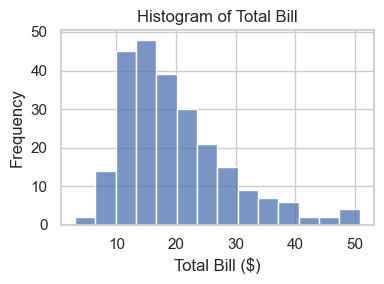

In [11]:
ax = sns.histplot(data=tips, x='total_bill')    ### sns.PLOT-TYPE(data=df, x='col_a', y='col_b', hue='col_c')
ax.set_title('Histogram of Total Bill')
ax.set_xlabel('Total Bill ($)')
ax.set_ylabel('Frequency')  
ax.figure.set_size_inches(4, 3)
plt.tight_layout()

- To control size, create an axes with Matplotlib and pass `ax=`. 
- Also, add `bins=` gives you different widths for the bars. In this case, we change from the default number of bins to 30 and we see more information about this distribution.

<Axes: xlabel='total_bill', ylabel='Count'>

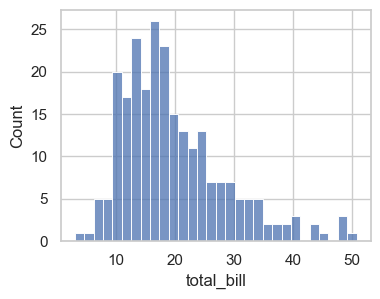

In [12]:
fig, ax = plt.subplots(figsize=(4, 3))
sns.histplot(data=tips, x='total_bill', bins=30, ax=ax)


In [13]:
### Exercise: Histogram for Total Bill
#   1. Create a figure and axes with figsize=(5, 3).
#   2. Plot a histogram of tips['total_bill'] using sns.histplot.
#   3. Use bins=20.
#   4. Set the title to 'Total Bill Distribution'.
### Your code starts here.




### Your code ends here.


Text(0.5, 1.0, 'Total Bill Distribution')

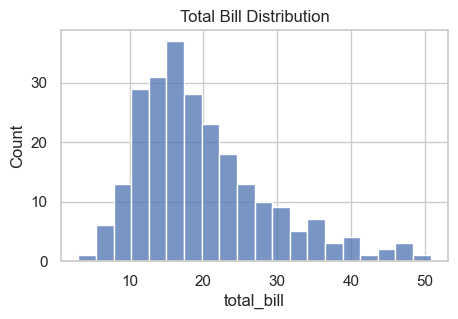

In [14]:
### Solution
fig, ax = plt.subplots(figsize=(5, 3))
sns.histplot(data=tips, x='total_bill', bins=20, ax=ax)
ax.set_title('Total Bill Distribution')


#### Bins, Alpha, and KDE

Three common controls:
- `bins`: granularity of histogram bars
- `alpha`: transparency
- `kde=True`: overlay smooth density estimate


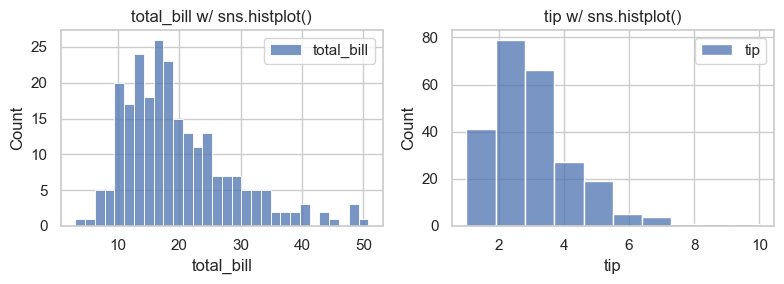

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
bins = [30, 10]
for i, col in enumerate(data.columns):
    sns.histplot(data[col], bins=bins[i], label=col, ax=axes[i])
    axes[i].set_title(f'{col} w/ sns.histplot()')
    axes[i].legend()
plt.tight_layout()


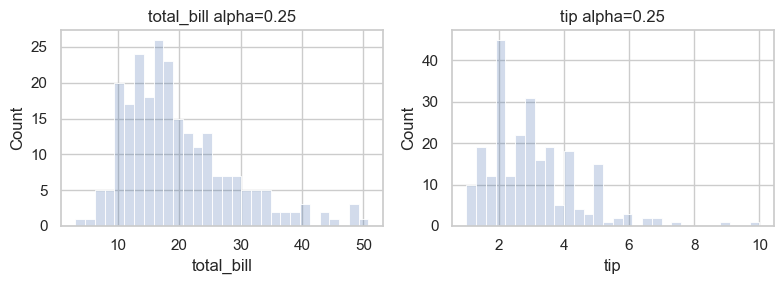

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for i, col in enumerate(data.columns[:2]):
    sns.histplot(data[col], alpha=0.25, bins=30, ax=axes[i])
    axes[i].set_title(f'{col} alpha=0.25')
plt.tight_layout()


To overlay KDE, set keyword argument `kde=True` when plotting.

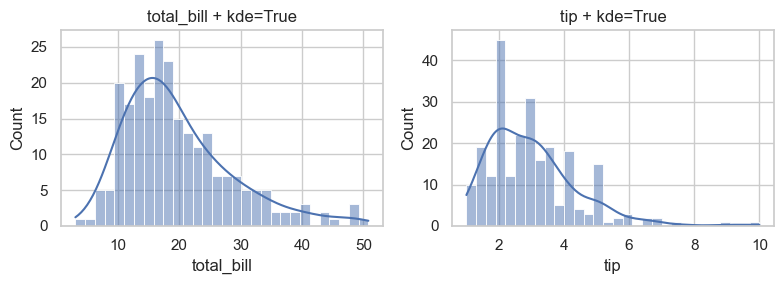

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for i, col in enumerate(data.columns):
    ### add kde=True for kernel density estimate overlay
    sns.histplot(data[col], alpha=0.5, bins=30, kde=True, ax=axes[i]) 
    axes[i].set_title(f'{col} + kde=True')
plt.tight_layout()


In [18]:
### Exercise: Compare Histogram Settings
#   1. Create fig, axes = plt.subplots(1, 2, figsize=(8, 3)).
#   2. On axes[0], plot tips['tip'] with bins=10 and title 'bins=10'.
#   3. On axes[1], plot tips['tip'] with bins=30, alpha=0.4, kde=True,
#      and title 'bins=30, alpha=0.4, kde=True'.
#   4. Call plt.tight_layout().
### Your code starts here.




### Your code ends here.


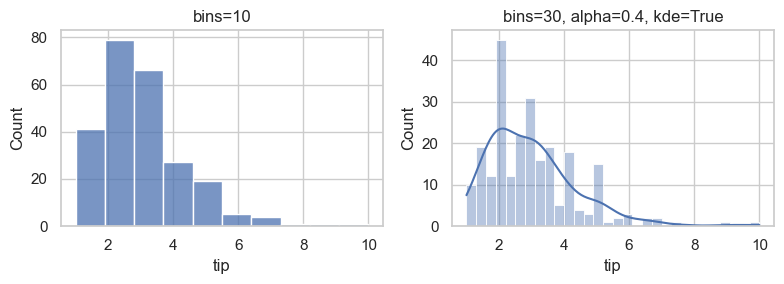

In [19]:
### Solution
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sns.histplot(tips['tip'], bins=10, ax=axes[0])
axes[0].set_title('bins=10')

sns.histplot(tips['tip'], bins=30, alpha=0.4, kde=True, ax=axes[1])
axes[1].set_title('bins=30, alpha=0.4, kde=True')

plt.tight_layout()


### KDE / Density

KDE is a smooth estimate of a distribution. It is often useful alongside histograms.


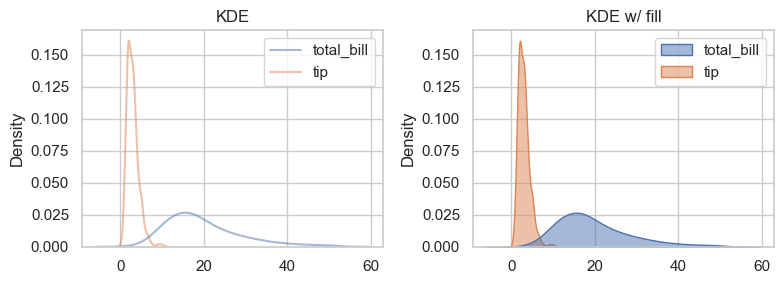

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sns.kdeplot(data=data, alpha=0.5, ax=axes[0])   ### seaborn ignores non-numeric columns, so no need to specify x or y
axes[0].set_title('KDE')

sns.kdeplot(data=data, alpha=0.5, ax=axes[1], fill=True)    ### add fill=True for filled KDE
axes[1].set_title('KDE w/ fill')

plt.tight_layout()


A 2D KDE is a smooth version of scatterplot.

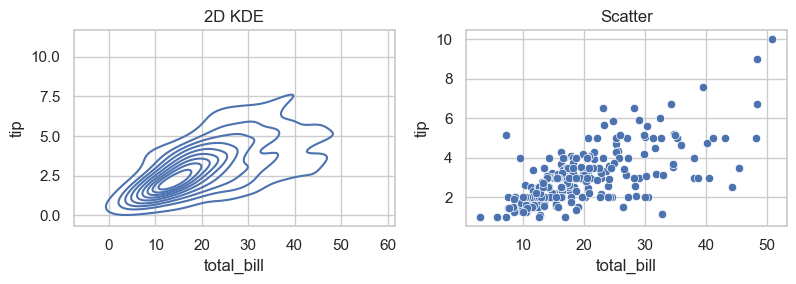

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sns.kdeplot(data=data, x='total_bill', y='tip', ax=axes[0])  ### specify x and y for 2D KDE
axes[0].set_title('2D KDE')

sns.scatterplot(data=data, x='total_bill', y='tip', ax=axes[1])
axes[1].set_title('Scatter')

plt.tight_layout()


Here we use density plot as an example of how Pandas visualization differs, syntactically, from Matplotlib and Seaborn:

| Library                | Function                | Notes                       |
| ---------------------- | ----------------------- | --------------------------- |
| **Seaborn**            | `sns.kdeplot()`         | most common, easy to use    |
| **Pandas**             | `.plot(kind="density")` | convenient for quick plots  |
| **Matplotlib + SciPy** | `gaussian_kde()`        | manual control over details |


In [22]:
### Exercise: KDE for Two Variables
#   1. Create fig, axes = plt.subplots(1, 2, figsize=(8, 3)).
#   2. On axes[0], draw sns.kdeplot for tips['total_bill'] with fill=True.
#   3. On axes[1], draw sns.kdeplot for tips['tip'] with fill=True.
#   4. Title the plots 'total_bill KDE' and 'tip KDE'.
#   5. Call plt.tight_layout().
### Your code starts here.




### Your code ends here.


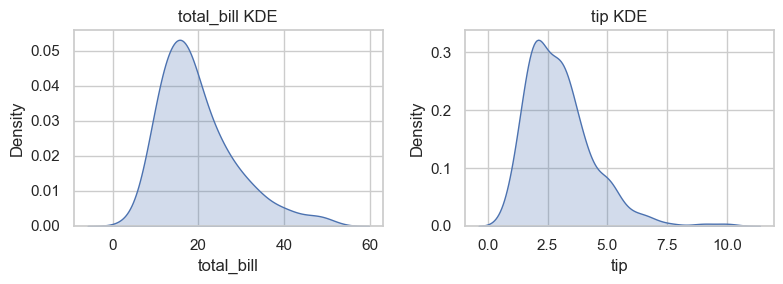

In [23]:
### Solution
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sns.kdeplot(tips['total_bill'], fill=True, ax=axes[0])
axes[0].set_title('total_bill KDE')

sns.kdeplot(tips['tip'], fill=True, ax=axes[1])
axes[1].set_title('tip KDE')

plt.tight_layout()


## Relational Plots

Relational plots show how variables move together (patterns, trends, clusters).


### Scatter Plot

<Axes: xlabel='total_bill', ylabel='tip'>

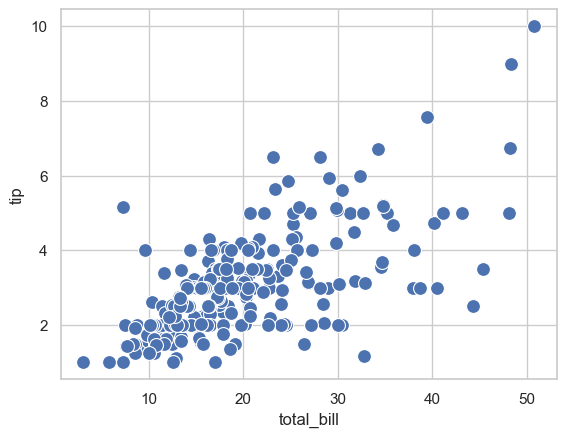

In [24]:
sns.scatterplot(x='total_bill', y='tip', data=tips, s=100, legend=True)

To control the figure size.

<Axes: xlabel='total_bill', ylabel='tip'>

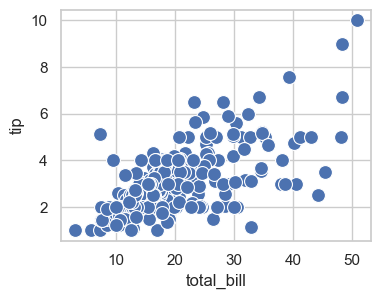

In [25]:
fig, ax = plt.subplots(figsize=(4, 3))
sns.scatterplot(x='total_bill', y='tip', data=tips, s=100, legend=True, ax=ax)

Add `hue=`

<Axes: xlabel='total_bill', ylabel='tip'>

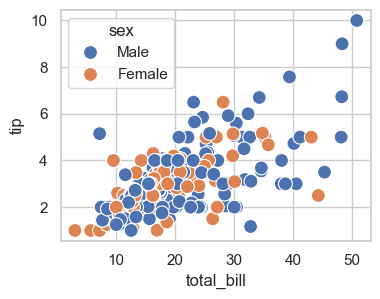

In [26]:
fig, ax = plt.subplots(figsize=(4, 3))
sns.scatterplot(x='total_bill', y='tip', data=tips, s=100, legend=True, ax=ax, hue='sex')

Add size and move legend out of the plot using `bbox_to_anchor=`. (*bbox == bounding box)

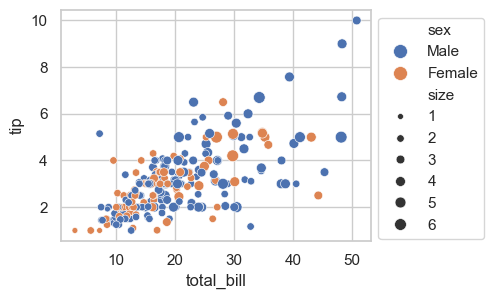

In [27]:
fig, ax = plt.subplots(figsize=(4, 3))
sns.scatterplot(x='total_bill', y='tip', data=tips, s=100, legend=True, ax=ax, hue='sex', size='size')
ax.legend(bbox_to_anchor=(1, 1))  ### move legend outside the plot

In [28]:
### Exercise: Scatter with Semantic Mapping
#   1. Create a scatter plot of total_bill vs tip.
#   2. Color points by time (hue='time').
#   3. Use marker size mapping from the 'size' column with sizes=(30, 180).
#   4. Set the title to 'Tips: Bill vs Tip by Time and Party Size'.
### Your code starts here.




### Your code ends here.


Text(0.5, 1.0, 'Tips: Bill vs Tip by Time and Party Size')

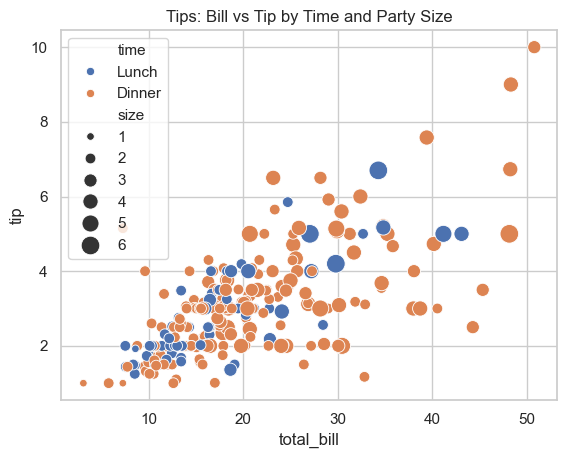

In [29]:
### Solution
ax = sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='time',
    size='size',
    sizes=(30, 180)
)
ax.set_title('Tips: Bill vs Tip by Time and Party Size')


### Line Plot

`lineplot` is commonly used for trends across an ordered x-axis. By default, seaborn aggregates repeated x values and can show uncertainty intervals.


<Axes: xlabel='day', ylabel='tip'>

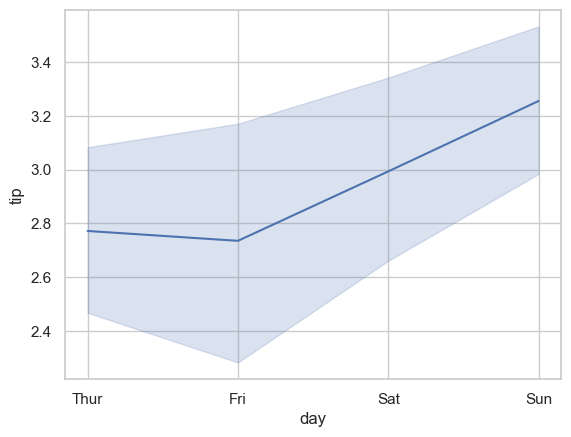

In [30]:
sns.lineplot(x='day', y='tip', data=tips, estimator='mean', errorbar=('ci', 95))

In [31]:
### Exercise: Average Tip by Day
#   1. Create a line plot with x='day' and y='tip' using the tips dataset.
#   2. Use estimator='mean'.
#   3. Keep a 95% confidence interval using errorbar=('ci', 95).
#   4. Set the title to 'Average Tip by Day'.
### Your code starts here.




### Your code ends here.


Text(0.5, 1.0, 'Average Tip by Day')

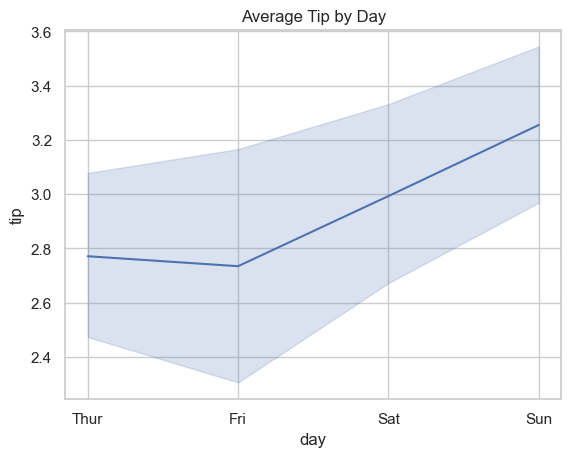

In [32]:
### Solution
ax = sns.lineplot(x='day', y='tip', data=tips, estimator='mean', errorbar=('ci', 95))
ax.set_title('Average Tip by Day')


## Categorical Plots

Categorical plots summarize or compare values across groups.


`sns.catplot()` is a figure-level wrapper for categorical plots (`kind='box'`, `'violin'`, `'bar'`, `'count'`, etc.).

Use it when you want consistent faceting/layout behavior across categorical plot types.


### Box Plot

:::{note}
The `with sns.axes_style(...)` block is a **context manager** that temporarily applies a style only to the plots created inside it. Once the block ends, Seaborn reverts to the previous theme — nothing is permanently changed.
:::


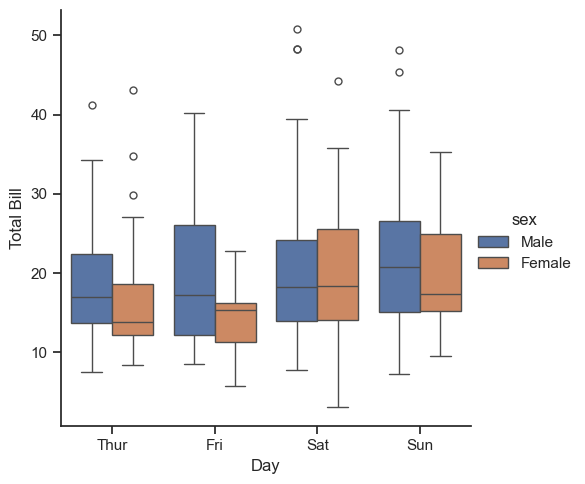

In [33]:
with sns.axes_style(style='ticks'):
    # g = sns.catplot(data=tips, x='day', y='total_bill', kind='box')
    g = sns.catplot(data=tips, x='day', y='total_bill', hue='sex', kind='box')
    g.set_axis_labels('Day', 'Total Bill')


In [34]:
### Exercise: Box Plot by Day and Sex
#   1. Use sns.catplot with kind='box'.
#   2. Plot x='day', y='total_bill', and hue='sex' from tips.
#   3. Set axis labels to 'Day' and 'Total Bill'.
### Your code starts here.




### Your code ends here.


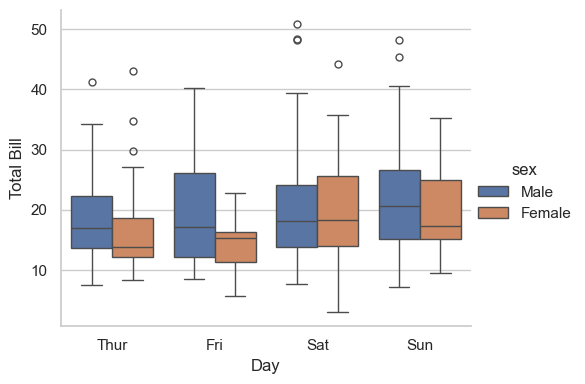

In [35]:
### Solution
g = sns.catplot(x='day', y='total_bill', hue='sex', data=tips, kind='box', height=4, aspect=1.25)
g.set_axis_labels('Day', 'Total Bill')


### Bar Plot

`bar` shows an **estimator** (mean by default) with uncertainty intervals. 
Also, here we explore different ways of plotting technics:

- Saving axes: Instead of using `subplots()`, we save the plot, which is an axes, and then control the styling directly. 
- The `with` statement: The `with` statement (the "context manager" that handles resources) temporarily applies a style only for the plots created inside its block. Once the block ends, Seaborn returns to the previous style — nothing is permanently changed. 


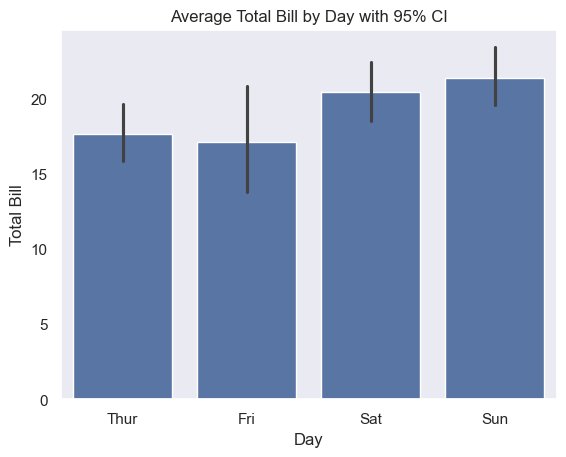

In [36]:
with sns.axes_style(style='dark'):
    g = sns.barplot(data=tips, x='day', y='total_bill', errorbar=('ci', 95))
    g.set_xlabel('Day')
    g.set_ylabel('Total Bill')
    g.set_title('Average Total Bill by Day with 95% CI')


Set `hue` and see the magic seaborn does.

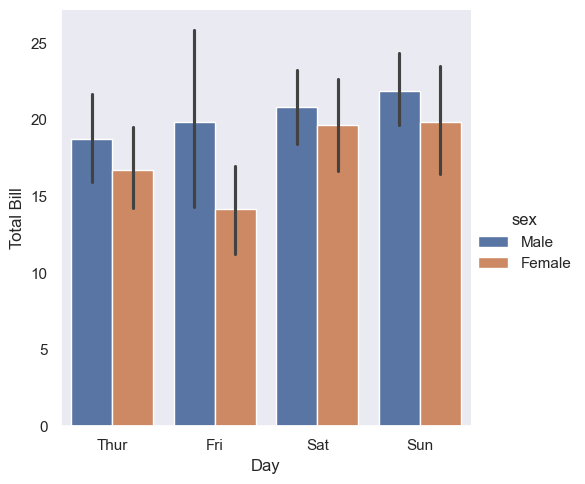

In [37]:
with sns.axes_style(style='dark'):
    g = sns.catplot(data=tips, x='day', y='total_bill', hue='sex', kind='bar', errorbar=('ci', 95))
    g.set_axis_labels('Day', 'Total Bill')


In [38]:
### Exercise: Mean Total Bill by Day
#   1. Create a categorical bar plot with x='day' and y='total_bill'.
#   2. Use kind='bar' and errorbar=('ci', 95).
#   3. Set axis labels to 'Day' and 'Total Bill'.
### Your code starts here.




### Your code ends here.


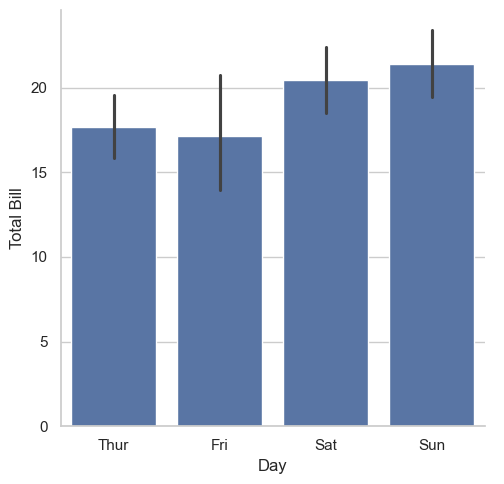

In [39]:
### Solution
g = sns.catplot(x='day', y='total_bill', data=tips, kind='bar', errorbar=('ci', 95))
g.set_axis_labels('Day', 'Total Bill')


### Count Plot (`kind='count'`)

Count plots show category frequencies. This is different from histograms, which bin continuous numeric values.


            method  number  orbital_period   mass  distance  year
0  Radial Velocity       1         269.300   7.10     77.40  2006
1  Radial Velocity       1         874.774   2.21     56.95  2008
2  Radial Velocity       1         763.000   2.60     19.84  2011
3  Radial Velocity       1         326.030  19.40    110.62  2007
4  Radial Velocity       1         516.220  10.50    119.47  2009


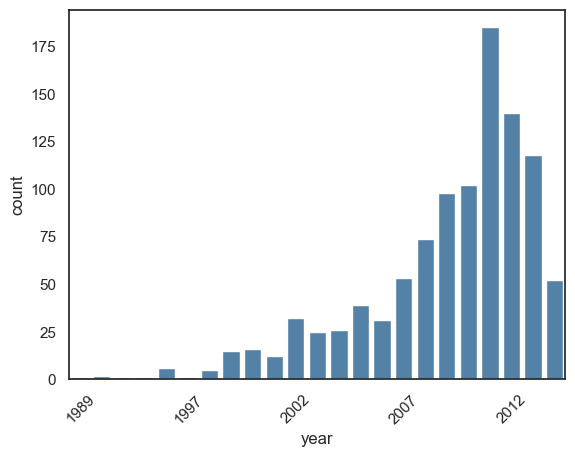

In [63]:
print(planets.head())

with sns.axes_style('white'):
    g = sns.countplot(
        data=planets, 
        x='year', 
        color='steelblue'
        )
    ticks = g.get_xticks()
    labels = [t.get_text() for t in g.get_xticklabels()]   # get labels before changing ticks

    g.set_xticks(ticks[::5])                    # set every 5th tick position
    g.set_xticklabels(labels[::5], rotation=45) # set every 5th label

### with figure level catplot:
# with sns.axes_style('white'):       ### with for temporary style
#     g = sns.catplot(
#         data=planets,
#         x='year',
#         aspect=2,           ### aspect ratio (width/height);
#         kind='count',
#         color='steelblue',
#         height=3
#     )


In [ ]:
### Exercise: Count Planets Discoveries by Year
#   1. Create a count plot using planets with x='year'.
#   2. Use kind='count', height=3, aspect=2, and color='steelblue'.
#   3. Set x tick labels to show every 5th year.
### Your code starts here.




### Your code ends here.


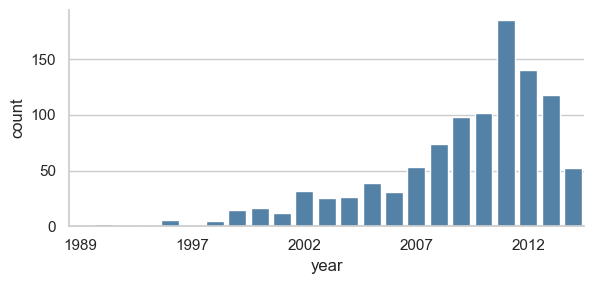

In [ ]:
### Solution
g = sns.catplot(
    x='year',
    data=planets,
    kind='count',
    height=3,
    aspect=2,
    color='steelblue'
)
g.set_xticklabels(step=5)
